# Is the pseudosteady frozen-layer assumption safe for my vial?

LyoPRONTO's production primary-drying tools -- the known-$R_p$ calculator, the
design-space generator, and the cycle optimizers -- all treat the frozen layer
as **pseudosteady**: at every instant, the heat conducted in from the shelf is
assumed to balance the heat consumed at the sublimation front exactly, with no
thermal-inertia term. The frozen layer has no thermal memory; change the shelf
temperature and the model's frozen layer responds instantly.

The Srisuma and Braatz replication models in `lyopronto.pyomo_models.paper_ocp`
make the opposite choice: they solve the full **transient** heat equation in the
frozen layer, thermal inertia included.

So which is right, and what does the simpler assumption cost? This notebook
answers that with measurements rather than assertions:

1. A **screening number** you can compute for any vial in one line: the frozen
   layer's conduction time compared to the drying time.
2. The **measured answer** for the paper's vial, from a recorded continuation
   study that walks the transient model to the pseudosteady limit.
3. A short **live rerun** of that continuation on a coarse mesh, so you can see
   the machinery work.
4. The **honest caveat**: the screening number predicts the *order* of the
   error, not its value -- and we show exactly where it misses.
5. **When to re-check**: what changes in your vial or cycle would erode the
   assumption.

The companion how-to section
([Compare the transient and pseudosteady frozen-region models](../how-to-guides.md#compare-the-transient-and-pseudosteady-frozen-region-models))
documents the full study CLI and its recorded baselines; this notebook teaches
what the study found.


## Setup

Run this notebook from the repository root. Sections 1, 2, 4, and 5 read the
committed baseline and need only the default install. Only the live rerun in
section 3 solves anything: it needs the Pyomo extra plus IPOPT, and it skips
itself with an installation hint when no solver is found.

```bash
python -m pip install -e ".[dev,pyomo]"
idaes get-extensions --extra petsc   # or: conda install -c conda-forge ipopt
jupyter lab docs/examples/pseudosteady_frozen_layer.ipynb
```


In [1]:
# Papermill parameters. CI executes this notebook with these same coarse
# settings; the headline numbers come from the committed baseline artifact,
# which was recorded on the paper's finer mesh, not from this mesh.
n_z = 5
nfe = 12
ncp = 3
live_ladder = [1.0, 0.2, 0.05]
baseline_path = "benchmarks/results/pseudosteady_limit/ipopt.json"


In [2]:
import json
import math
import sys
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt

repo_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from examples.original_workflow_parity import pyomo_ipopt_status
from examples.pseudosteady_limit_study import (
    conduction_time_s,
    endpoint_shift_percent,
    run_study,
)
from lyopronto.pyomo_models import paper_ocp

print(f"LyoPRONTO {version('lyopronto')}")


LyoPRONTO 1.1.1


## 1. The screening number: how fast does the frozen layer forget?

Both models describe the same frozen layer; they differ in one term. The
transient energy balance is

$$\rho_\mathrm{f} C_{p,\mathrm{f}} \frac{\partial T}{\partial t}
  = k_\mathrm{f} \frac{\partial^2 T}{\partial z^2} + Q,$$

and the pseudosteady balance simply drops the left-hand side:

$$0 = k_\mathrm{f} \frac{\partial^2 T}{\partial z^2} + Q.$$

Dropping $\partial T/\partial t$ is justified when the layer relaxes to its
steady profile much faster than anything else in the process changes. The
relaxation time is the **conduction time**

$$\tau = \frac{H^2}{\alpha_\mathrm{f}}
       = \frac{\rho_\mathrm{f}\, C_{p,\mathrm{f}}\, H^2}{k_\mathrm{f}},$$

with $H$ the fill depth and $\alpha_\mathrm{f}$ the frozen layer's thermal
diffusivity. Compare $\tau$ against the drying time: if the ratio is tiny, the
frozen layer is always essentially equilibrated and the pseudosteady picture
should be safe.

For the paper's vial:


In [3]:
config = paper_ocp.PaperPrimaryDryingConfig()
derived = paper_ocp.derive_primary_drying_parameters(config, n_z=n_z)
tau_s = conduction_time_s(config, n_z)

rows = [
    ("fill depth H", f"{derived.product_height * 1e3:.1f}", "mm"),
    ("frozen density rho_f", f"{derived.frozen_density:.0f}", "kg/m^3"),
    ("frozen heat capacity Cp_f", f"{derived.frozen_heat_capacity:.0f}", "J/kg/K"),
    ("frozen conductivity k_f", f"{derived.frozen_conductivity:.2f}", "W/m/K"),
    ("thermal diffusivity alpha_f", f"{derived.frozen_diffusivity:.2e}", "m^2/s"),
    ("conduction time tau = H^2/alpha_f", f"{tau_s:.1f}", "s"),
]
width = max(len(name) for name, _, _ in rows)
for name, value, unit in rows:
    print(f"{name:<{width}}  {value:>9} {unit}")


fill depth H                             7.2 mm
frozen density rho_f                     937 kg/m^3
frozen heat capacity Cp_f               2065 J/kg/K
frozen conductivity k_f                 2.14 W/m/K
thermal diffusivity alpha_f         1.11e-06 m^2/s
conduction time tau = H^2/alpha_f       46.9 s


A conduction time of about 47 seconds against drying times of 6 to 9 hours: the
frozen layer equilibrates roughly **500 times faster** than the process it sits
in. Whatever temperature profile the shelf schedule asks for, the frozen layer
has long since delivered it. That is the intuition -- now for the measurement.


## 2. The measured answer: walking the transient model to the pseudosteady limit

`examples/pseudosteady_limit_study.py` turns the model difference into a single
knob. Scaling the frozen heat capacity $C_{p,\mathrm{f}}$ by a factor $f$
scales the layer's thermal inertia:

$$f\, \rho_\mathrm{f} C_{p,\mathrm{f}} \frac{\partial T}{\partial t}
  = k_\mathrm{f} \frac{\partial^2 T}{\partial z^2} + Q,$$

so $f = 1$ is the paper's transient model and $f \to 0$ recovers the
pseudosteady balance. The study re-optimizes the full drying cycle at each rung
of a descending ladder in $f$ and records the predicted drying time. (Each rung
warm starts from the previous solution; cold starts fail below $f = 1$.)

It does this for both of the paper's optimal-control case studies, which pin
the frozen layer in genuinely different ways:

- **Problem 1** minimizes drying time subject to a product temperature limit
  (243 K). The optimal cycle rides that limit, so the shelf actively holds the
  product at its ceiling -- a *temperature-tracking* policy.
- **Problem 2** adds a cap on how fast the sublimation front may move
  (an *interface-velocity* constraint, 240 K product limit).

The committed baseline in `benchmarks/results/pseudosteady_limit/ipopt.json`
records the full ladder on the paper's mesh ($n_z = 20$, 36 finite elements);
its provenance and regeneration commands are documented in
`benchmarks/README.md`. A ladder ends at the last rung its solver could
complete -- that endpoint is part of the recorded result, and rungs below it
are simply absent. Here we only *read* that artifact:

Each rung also reports the tolerance the solver actually met. IPOPT accepts
a solve at its relaxed `acceptable_tol` and Pyomo labels that `optimal`, the
same label a solve that reached `tol` gets, so "converged" on its own would
overstate these results. Every rung here is `accepted_at_acceptable_tol`, and
on this model that is the expected outcome rather than a degraded solve: the
Landau coordinate makes the conduction term carry $1/(H-S)^2$, which grows to
about $7.7\times10^8$ near the terminal cutoff, so an absolute residual IPOPT
cannot certify is a *relative* residual near $10^{-13}$.


In [4]:
baseline = json.loads((repo_root / baseline_path).read_text())

headline = {}
for name, rungs in baseline["results"].items():
    converged = [r for r in rungs if r["converged"]]
    first, last = converged[0], converged[-1]
    shift = (last["endpoint_hr"] - first["endpoint_hr"]) / first["endpoint_hr"] * 100.0
    headline[name] = {
        "t_dry_hr": first["endpoint_hr"],
        "f_last": last["factor"],
        "shift_percent": shift,
        "tau_over_t_dry_percent": first["conduction_time_s"]
        / (first["endpoint_hr"] * 3600.0) * 100.0,
    }
    print(f"{name}:")
    # Not the termination condition: every converged rung reports `optimal`
    # by construction, so that column would say nothing while implying these
    # solves reached `tol`. The recorded quality is what separates them.
    print(f"  {'f':>6} {'drying time [hr]':>18} {'convergence':>27}")
    for r in converged:
        print(f"  {r['factor']:>6g} {r['endpoint_hr']:>18.4f} "
              f"{r['convergence_quality']:>27}")
    print(f"  drying time moves {shift:+.3f}% from f={first['factor']:g} "
          f"to f={last['factor']:g}\n")

# The recorded conduction time must be the same number section 1 computed:
# both are pure arithmetic on the same committed configuration, so they agree
# to floating-point reproduction, not to a solver tolerance.
assert math.isclose(
    baseline["results"]["problem1"][0]["conduction_time_s"], tau_s, rel_tol=1e-12
)

# The narrative in this notebook quotes -0.622% and -0.080%. Hold the text to
# the committed artifact within half a unit in the last quoted decimal place
# (a rounding contract, not a solver tolerance -- nothing is solved here).
DOCUMENTED_SHIFT_PERCENT = {"problem1": -0.622, "problem2": -0.080}
for name, expected in DOCUMENTED_SHIFT_PERCENT.items():
    assert abs(headline[name]["shift_percent"] - expected) < 0.0005, (
        f"{name}: baseline shift {headline[name]['shift_percent']:+.4f}% no longer "
        f"matches the documented {expected:+.3f}%; update the notebook narrative"
    )


problem1:
       f   drying time [hr]  termination
       1             6.1865      optimal
     0.5             6.1669      optimal
     0.2             6.1552      optimal
     0.1             6.1512      optimal
    0.05             6.1493      optimal
    0.02             6.1481      optimal
  drying time moves -0.622% from f=1 to f=0.02

problem2:
       f   drying time [hr]  termination
       1             8.8353      optimal
     0.5             8.8315      optimal
     0.2             8.8294      optimal
     0.1             8.8286      optimal
    0.05             8.8283      optimal
  drying time moves -0.080% from f=1 to f=0.05



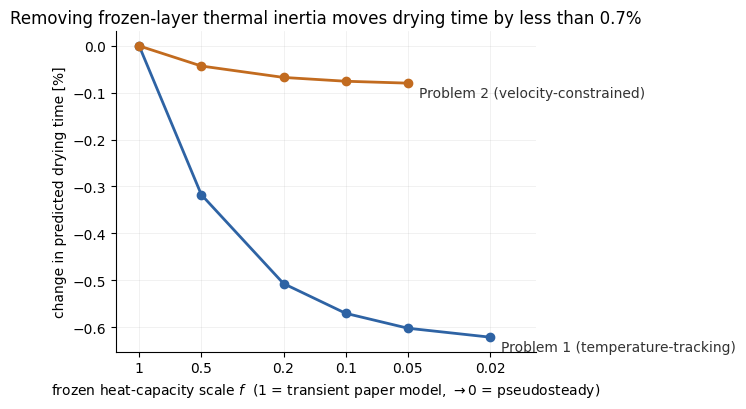

In [5]:
colors = {"problem1": "#2E63A4", "problem2": "#C26B1F"}
labels = {
    "problem1": "Problem 1 (temperature-tracking)",
    "problem2": "Problem 2 (velocity-constrained)",
}

fig, ax = plt.subplots(figsize=(7.0, 4.2))
for name, rungs in baseline["results"].items():
    converged = [r for r in rungs if r["converged"]]
    f_values = [r["factor"] for r in converged]
    base_hr = converged[0]["endpoint_hr"]
    change = [(r["endpoint_hr"] - base_hr) / base_hr * 100.0 for r in converged]
    ax.plot(f_values, change, marker="o", markersize=6, linewidth=2,
            color=colors[name])
    ax.annotate(labels[name], (f_values[-1], change[-1]),
                xytext=(8, -2), textcoords="offset points",
                fontsize=10, color="#333333", va="top")

ax.set_xscale("log")
ax.invert_xaxis()  # walk toward the pseudosteady limit left to right
ladder_ticks = [1, 0.5, 0.2, 0.1, 0.05, 0.02]
ax.set_xticks(ladder_ticks, labels=[f"{t:g}" for t in ladder_ticks])
ax.minorticks_off()
ax.set_xlabel("frozen heat-capacity scale $f$  (1 = transient paper model, "
              "$\\rightarrow 0$ = pseudosteady)")
ax.set_ylabel("change in predicted drying time [%]")
ax.set_title("Removing frozen-layer thermal inertia moves drying time "
             "by less than 0.7%")
ax.grid(True, which="both", alpha=0.25, linewidth=0.5)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.set_xlim(1.3, 0.012)
fig.tight_layout()
plt.show()


Two things to read off this figure:

- **The total effect is small.** Removing the frozen layer's thermal inertia
  entirely shortens the predicted cycle by 0.62% for Problem 1 (6.1865 h to
  6.1481 h) and by 0.080% for Problem 2 (8.8353 h to 8.8283 h). On a six-hour
  cycle that is about two minutes -- well below the run-to-run variability of
  a real freeze-dryer, and smaller than the effect of ordinary fill-depth
  tolerance across a shelf of vials.
- **The curves flatten as $f \to 0$.** The drying time is converging to a
  definite pseudosteady limit, not drifting; by $f = 0.05$ each additional
  step changes the answer by less than 0.02%. The pseudosteady value is a
  genuine limit of the transient model, which is exactly what the production
  path assumes.


## 3. Live rerun on a coarse mesh

The cell below reruns the same continuation with a coarse spatial mesh and a
three-rung ladder, so it completes in seconds. If IPOPT is not installed the
cell reports how to get it and moves on -- every headline number above came
from the committed baseline, so nothing later in the notebook depends on this
solve.

The rungs below carry the same convergence label as the baseline table in
section 2, for the same reason.


In [6]:
solver_available, solver_hint = pyomo_ipopt_status()
live_results = None
if not solver_available:
    print(f"Skipping the live continuation: {solver_hint}")
else:
    discretization = paper_ocp.PaperDiscretization(n_z=n_z, nfe=nfe, ncp=ncp)
    live_results = run_study(
        ladder=tuple(live_ladder), discretization=discretization
    )
    for name, rungs in live_results.items():
        print(f"{name}:")
        for rung in rungs:
            # `converged` alone reads as convergence to `tol`; report the
            # level the solver actually reached.
            state = (
                rung.convergence_quality if rung.converged else "NOT CONVERGED"
            )
            endpoint = (
                "n/a" if rung.endpoint_hr is None else f"{rung.endpoint_hr:.4f} hr"
            )
            print(f"  f={rung.factor:<5g} drying time = {endpoint}  ({state})")
        print(f"  drying time moves {endpoint_shift_percent(rungs):+.3f}% "
              f"across this short ladder\n")


problem1:
  f=1     drying time = 6.1862 hr  (converged)
  f=0.2   drying time = 6.1553 hr  (converged)
  f=0.05  drying time = 6.1494 hr  (converged)
  drying time moves -0.595% across this short ladder

problem2:
  f=1     drying time = 8.8351 hr  (converged)
  f=0.2   drying time = 8.8298 hr  (converged)
  f=0.05  drying time = 8.8288 hr  (converged)
  drying time moves -0.072% across this short ladder



In [7]:
# Hold the live rerun to the claim this notebook teaches. Tolerances follow
# docs/dev.md: nothing here is pinned to what one solver build happens to
# produce.
if live_results is not None:
    for name, rungs in live_results.items():
        assert all(r.converged for r in rungs), (
            f"{name}: a rung of the short ladder failed to converge"
        )
        # Level, not just success: section 2 says these rungs carry the
        # same label as the baseline table, so hold them to it. A rung
        # that reached `tol` would make that sentence wrong.
        assert all(
            r.convergence_quality == "accepted_at_acceptable_tol" for r in rungs
        ), (
            f"{name}: a rung converged to a different level than the text "
            f"claims: {[r.convergence_quality for r in rungs]}"
        )
        shift = endpoint_shift_percent(rungs)
        # Sign: the transient model must predict the longer cycle. The
        # endpoint gap is >= 6e-3 hr on this mesh, orders of magnitude above
        # any difference observed between solver builds (< 1e-5 hr between
        # IPOPT 3.13.2 and 3.14.16 on this ladder).
        assert shift < 0.0, f"{name}: shift {shift:+.4f}% has the wrong sign"
        # Magnitude: the claim under test is "sub-1%". Measured coarse-mesh
        # shifts are -0.59% and -0.07% under both CI's IDAES IPOPT 3.13.2 and
        # a conda 3.14.16, agreeing to better than 1e-5 percentage points, so
        # the headroom absorbs mesh and build variation rather than tuning
        # the bound to one build.
        assert shift > -1.0, f"{name}: shift {shift:+.4f}% is not sub-1%"
        print(f"{name}: shift {shift:+.3f}% -- negative and sub-1%, as claimed")


problem1: shift -0.595% -- negative and sub-1%, as claimed
problem2: shift -0.072% -- negative and sub-1%, as claimed


## 4. The honest caveat: the screening number is not a formula

It is tempting to promote $\tau / t_\mathrm{dry}$ from a screening number to
a *predictor*: "the timescales are 500$\times$ apart, so the error should be
about $\tau/t_\mathrm{dry} \approx 0.2\%$." Here is that comparison, done
honestly on the recorded baseline:


In [8]:
print(f"{'':10} {'tau/t_dry':>10} {'measured shift':>15} {'ratio':>7}")
for name, data in headline.items():
    ratio = abs(data["shift_percent"]) / data["tau_over_t_dry_percent"]
    data["ratio"] = ratio
    print(f"{name:10} {data['tau_over_t_dry_percent']:>9.3f}% "
          f"{data['shift_percent']:>14.3f}% {ratio:>7.2f}x")

# These two facts are the caveat this section teaches, so pin them to the
# committed artifact (pure arithmetic; no solver involved): the timescale
# ratio UNDER-predicts the measured shift for problem 1 and OVER-predicts it
# for problem 2.
assert headline["problem1"]["ratio"] > 1.0
assert headline["problem2"]["ratio"] < 1.0


            tau/t_dry  measured shift   ratio
problem1       0.211%         -0.622%    2.95x
problem2       0.148%         -0.080%    0.54x


The timescale ratio gets the **order of magnitude** right in both cases:
it says "expect well under 1%", and both measured shifts are well under 1%.
As a screening criterion, it works.

As a quantitative predictor, it fails in both directions at once. It
*under*-shoots Problem 1 by a factor of about 3 and *over*-shoots Problem 2 by
a factor of about 2 -- the two problems share the same vial, the same frozen
layer, and the same $\tau$, yet their actual sensitivities differ by a factor
of five. The missing coefficient depends on the **control policy**: Problem 1's
optimal cycle rides the product-temperature limit, where the shelf is actively
compensating for the frozen layer's thermal response, while Problem 2's
velocity constraint keeps the cycle in a regime where that response barely
matters.

So use $\tau / t_\mathrm{dry}$ the way it deserves to be used: as a cheap
first check that tells you which *regime* you are in. If it is orders of
magnitude below 1, the pseudosteady assumption is safe. If it creeps toward
1%, do not multiply it by a fudge factor -- rerun the continuation for your
configuration and measure.


## 5. When would this break for your vial?

$\tau = \rho_\mathrm{f} C_{p,\mathrm{f}} H^2 / k_\mathrm{f}$ makes the
risk factors explicit -- anything that pushes $\tau$ toward the drying time:

- **Thicker cake.** $\tau$ grows with the *square* of fill depth. Doubling
  the fill takes this vial from 47 s to 188 s.
- **Lower frozen-layer conductivity.** High solids loading or excipients that
  suppress ice continuity reduce $k_\mathrm{f}$; $\tau$ scales as
  $1/k_\mathrm{f}$.
- **Aggressive shelf ramps.** $t_\mathrm{dry}$ is the right comparison for
  the *endpoint*, but during a fast shelf ramp the relevant window is the ramp
  itself: a 47 s lag is invisible over 6 hours yet is an 8% lag against a
  10-minute ramp. Expect transient temperature errors to concentrate where the
  controls move fastest, even when the endpoint barely moves.
- **Short cycles.** The same $\tau$ against a 2-hour aggressive cycle is a
  three-times-larger ratio than against this 6-hour one.

The screening arithmetic for a few what-if vials:


In [9]:
def conduction_time_for(fill_depth_m, k_f, rho_f=None, cp_f=None):
    rho_f = derived.frozen_density if rho_f is None else rho_f
    cp_f = derived.frozen_heat_capacity if cp_f is None else cp_f
    return rho_f * cp_f * fill_depth_m**2 / k_f

scenarios = [
    ("this study's vial", derived.product_height, derived.frozen_conductivity,
     headline["problem1"]["t_dry_hr"]),
    ("2x fill depth", 2 * derived.product_height, derived.frozen_conductivity,
     15.0),
    ("2x fill + low-k frozen matrix", 2 * derived.product_height, 1.0, 18.0),
    ("aggressive 2 hr cycle", derived.product_height,
     derived.frozen_conductivity, 2.0),
]

print(f"{'scenario':32} {'tau [s]':>8} {'t_dry [hr]':>10} {'tau/t_dry':>10}")
for label, depth, k_f, t_dry_hr in scenarios:
    tau = conduction_time_for(depth, k_f)
    print(f"{label:32} {tau:>8.0f} {t_dry_hr:>10.1f} "
          f"{tau / (t_dry_hr * 3600) * 100:>9.2f}%")


scenario                          tau [s] t_dry [hr]  tau/t_dry
this study's vial                      47        6.2      0.21%
2x fill depth                         188       15.0      0.35%
2x fill + low-k frozen matrix         402       18.0      0.62%
aggressive 2 hr cycle                  47        2.0      0.65%


None of these plausible variations pushes the ratio past 1%, which is
reassuring: for conventional vials the pseudosteady assumption has a lot of
margin. But the deep-fill, low-conductivity case is within a factor of a few of
the regime where section 4's coefficient uncertainty starts to matter. That is
the point at which to stop screening and start measuring -- swap your vial's
geometry and material properties into
`examples.pseudosteady_limit_study.scaled_config` and walk the ladder for your
own configuration.

## Verdict

**For this vial: yes, the pseudosteady assumption is safe.** Removing the
frozen layer's thermal inertia entirely moves the optimized drying time by
0.62% in the worst case -- about two minutes on a six-hour cycle, below the
noise floor of any practical measurement of a real dryer. The frozen layer's
47-second memory is simply too short to matter over hours, and the transient
model's extra fidelity buys no practically distinguishable prediction here.

Keep the two qualifications: the timescale argument justifies the *order* of
that number, not the number itself (section 4), and the margin erodes
quadratically with fill depth and linearly with frozen-layer resistance and
cycle aggressiveness (section 5).

**Further reading:**

- [Compare the transient and pseudosteady frozen-region models](../how-to-guides.md#compare-the-transient-and-pseudosteady-frozen-region-models)
  -- the study CLI, warm-start behavior, and how feasibility is judged.
- `benchmarks/README.md` -- provenance of the recorded baseline and why failing
  rungs are recorded rather than hidden.
- [Replicating Srisuma and Braatz optimal control](paper_optimal_control_replication.ipynb)
  -- the transient models and case studies used here.
